# Sistemi lineari, condizionamento e metodi diretti

Questo notebook presenta alcuni numerici per la risoluzione di sistemi lineari ed il concetto di condizionamento.  

Argomenti:

1. il problema $Ax=b$;
2. limiti della regola di Cramer;
3. perché evitare il calcolo esplicito dell'inversa;
4. norme vettoriali e matriciali;
5. errore assoluto e relativo;
6. condizionamento rispetto a perturbazioni su $b$;
7. condizionamento rispetto a perturbazioni su $A$;
8. sistemi triangolari;
9. fattorizzazione LU;
10. eliminazione di Gauss;
11. pivoting parziale;
12. stabilità numerica;
13. algoritmo di Thomas;
14. fattorizzazione di Cholesky;
15. fattorizzazione QR;
16. trasformazioni di Householder;
17. esercizi ed esperimenti.

In [3999]:
import numpy as np
import math
import time

np.set_printoptions(precision=6, suppress=True)

# Parte I — Il problema $Ax=b$

## 1. Formulazione del problema

Uno dei problemi più frequenti nel calcolo scientifico è la soluzione di un sistema lineare.  
Un sistema lineare quadrato, cioè con tante equazioni quante incognite, si scrive in forma matriciale come

$$
Ax=b,
$$

dove

$$
A\in\mathbb{R}^{n\times n},\qquad
x\in\mathbb{R}^{n},\qquad
b\in\mathbb{R}^{n}.
$$

La matrice $A$ contiene i _coefficienti_, il vettore $b$ contiene i _termini noti_ e $x$ è il _vettore delle incognite_.

>Se $A$ è non singolare, cioè invertibile, il sistema ha una e una sola soluzione.

### Esempio elementare

Consideriamo

$$
\begin{cases}
2x_1+x_2=1,\\
x_1+3x_2=2.
\end{cases}
$$

In forma matriciale:

$$
\begin{pmatrix}
2 & 1\\
1 & 3
\end{pmatrix}
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}
=
\begin{pmatrix}
1\\
2
\end{pmatrix}.
$$

In [4000]:
A = np.array([[2., 1.],
              [1., 3.]])
b = np.array([1., 2.])

x = np.linalg.solve(A, b)

print("A =")
print(A)
print("b =", b)
print("Soluzione x =", x)
print("Verifica A @ x =", A @ x)

A =
[[2. 1.]
 [1. 3.]]
b = [1. 2.]
Soluzione x = [0.2 0.6]
Verifica A @ x = [1. 2.]


_Ma cosa c'è dietro al comando np.linalg.solve?_ 

### Matrici singolari e non singolari

La frase precedente, "se $A$ è non singolare", merita di essere precisata.  
Per una matrice quadrata $A\in\mathbb{R}^{n\times n}$, le seguenti proprietà sono equivalenti:

- $A$ è **non singolare**;
- esiste l'inversa $A^{-1}$;
- $\det(A)\neq 0$;
- $\operatorname{rank}(A)=n$, cioè le colonne di $A$ sono linearmente indipendenti;
- per ogni vettore $z\neq 0$ si ha $Az\neq 0$;
- se $\lambda_i$ sono gli autovalori di $A$, allora $\lambda_i\neq 0$ per ogni $i$.

Queste caratterizzazioni dicono la stessa cosa da punti di vista diversi: algebraico, geometrico e spettrale.  
In particolare, $Az=0$ deve avere come unica soluzione $z=0$. Se esiste invece un vettore non nullo $z$ tale che $Az=0$, allora $A$ è **singolare**.

### Esistenza e unicità della soluzione

L'esistenza e l'unicità della soluzione di

$$
Ax=b
$$

dipendono dal fatto che $A$ sia singolare o non singolare. Nel caso non singolare il comportamento è semplice: per ogni termine noto $b$ esiste una e una sola soluzione.

Nel caso singolare, invece, bisogna guardare anche il vettore $b$.  
Indichiamo con $R(A)$ l'insieme di tutti i vettori che si possono ottenere come combinazione lineare delle colonne di $A$:

$$
R(A)=\left\{z\in\mathbb{R}^n:\ z=\sum_{i=1}^{n}c_i a_i,\quad c_i\in\mathbb{R}\right\},
$$

dove $a_i$ è la $i$-esima colonna di $A$. Questo insieme si chiama **range** o **spazio colonnare** di $A$.

Il sistema $Ax=b$ è compatibile se e solo se

$$
b\in R(A),
$$

cioè se $b$ può essere scritto come combinazione lineare delle colonne di $A$.

| Tipo di matrice $A$ | Condizione su $b$ | Numero di soluzioni |
|---|---:|---:|
| $A$ non singolare | qualunque $b$ | una sola soluzione |
| $A$ singolare | $b\in R(A)$ | infinite soluzioni |
| $A$ singolare | $b\notin R(A)$ | nessuna soluzione |

Quindi, quando $A$ è singolare, non basta chiedersi se il determinante sia nullo: occorre anche stabilire se il termine noto $b$ appartiene allo spazio generato dalle colonne di $A$.

Da questo momento in poi, ci occuperemo esclusivamente del caso corrispondente alla prima riga della tabella.



## 2. Regola di Cramer: corretta ma impraticabile

La regola di Cramer scrive la componente $i$-esima della soluzione come

$$
x_i = \frac{\det(A_i)}{\det(A)},
$$

dove $A_i$ è la matrice ottenuta sostituendo la colonna $i$-esima di $A$ con $b$.

Dal punto di vista teorico è una formula elegante.  
Dal punto di vista numerico è una pessima strategia per sistemi anche solo moderatamente grandi.

Per risolvere un sistema di ordine $n$, Cramer richiede:

- $n+1$ determinanti;
- $n$ divisioni finali.

Se i determinanti sono calcolati con formule dirette, il costo cresce circa come $n!$.  
Questo rende il metodo inutilizzabile in pratica.

In [4001]:
for n in [5, 10, 15, 20]:
    ops_det = (n - 1) * math.factorial(n)
    ops_cramer = (n + 1) * ops_det
    print(f"n={n:2d}: operazioni stimate per Cramer ~ {ops_cramer:.3e}")

n= 5: operazioni stimate per Cramer ~ 2.880e+03
n=10: operazioni stimate per Cramer ~ 3.593e+08
n=15: operazioni stimate per Cramer ~ 2.929e+14
n=20: operazioni stimate per Cramer ~ 9.707e+20


## 3. Perché non calcolare esplicitamente $A^{-1}$

Poiché

$$
Ax=b,
$$

se $A$ è invertibile si può scrivere formalmente

$$
x=A^{-1}b.
$$

Tuttavia, per risolvere un sistema lineare, calcolare esplicitamente $A^{-1}$ è di solito sconsigliato.

Motivi:

1. richiede più operazioni;
2. introduce arrotondamenti intermedi non necessari;
3. se si vuole solo $x$, non serve conoscere tutta l'inversa.

In Python è preferibile usare:

```python
np.linalg.solve(A, b)
```

invece di:

```python
np.linalg.inv(A) @ b
```

In [4002]:
A = np.array([[4., 2.],
              [1., 3.]])
b = np.array([1., 2.])

x_solve = np.linalg.solve(A, b)
x_inv = np.linalg.inv(A) @ b

print("Soluzione con solve:", x_solve)
print("Soluzione con inversa:", x_inv)
print("Differenza:", np.linalg.norm(x_solve - x_inv))

Soluzione con solve: [-0.1  0.7]
Soluzione con inversa: [-0.1  0.7]
Differenza: 1.2412670766236366e-16


## 4. Errore inerente e condizionamento

Prima di scegliere un algoritmo, bisogna capire quanto il problema sia sensibile agli errori nei dati.

Nella pratica $A$ e $b$ possono essere perturbati perché:

- provengono da misure sperimentali;
- sono risultati di calcoli precedenti;
- sono rappresentati in aritmetica floating point;
- sono dati approssimati.

Quindi, invece di risolvere esattamente

$$
Ax=b,
$$

potremmo risolvere un problema perturbato:

$$
A\tilde{x}=b+\delta b
$$

oppure

$$
(A+\delta A)\tilde{x}=b.
$$

oppure ancora 

$$
(A+\delta A)\tilde{x}=b+\delta b.
$$

Il **condizionamento** studia come le perturbazioni sui dati influenzano la soluzione. 

Per questo occorre introdurre il concetto di errore, che è intrinsecamente legato a quello di _grandezza_ di un vettore.

# Parte II — Norme ed errori

## 5. Norme vettoriali

Una norma vettoriale è una funzione

$$
\|\cdot\|:\mathbb{R}^n\to\mathbb{R}
$$

che misura la grandezza di un vettore.

Deve soddisfare:

1. $\|x\|\ge 0$ e $\|x\|=0$ se e solo se $x=0$;
2. $\|x+y\|\le\|x\|+\|y\|$;
3. $\|\alpha x\|=|\alpha|\|x\|$.

Le norme più usate sono:

$$
\|x\|_1=\sum_{i=1}^{n}|x_i|,
$$

$$
\|x\|_2=\sqrt{\sum_{i=1}^{n}x_i^2},
$$

$$
\|x\|_\infty=\max_i |x_i|.
$$

In [4003]:
x = np.array([3., -4., 12.])

print("x =", x)
print("||x||_1   =", np.linalg.norm(x, 1))
print("||x||_2   =", np.linalg.norm(x, 2))
print("||x||_inf =", np.linalg.norm(x, np.inf))

x = [ 3. -4. 12.]
||x||_1   = 19.0
||x||_2   = 13.0
||x||_inf = 12.0


## 6. Interpretazione delle norme

La norma $\|x\|_2$ è la distanza euclidea usuale.

La norma $\|x\|_1$ somma il contributo assoluto di tutte le componenti.  
In due dimensioni è spesso chiamata _distanza Manhattan_.

La norma $\|x\|_\infty$ guarda solo la componente massima in valore assoluto.

Le norme non danno lo stesso numero, ma in dimensione finita sono equivalenti: se una successione tende a zero in una norma, tende a zero anche nelle altre.

In [4004]:
vectors = [
    np.array([1., 0.]),
    np.array([1., 1.]),
    np.array([2., -3.]),
    np.array([-4., 1.])
]

for v in vectors:
    print("v =", v)
    print("  ||v||_1   =", np.linalg.norm(v, 1))
    print("  ||v||_2   =", np.linalg.norm(v, 2))
    print("  ||v||_inf =", np.linalg.norm(v, np.inf))

v = [1. 0.]
  ||v||_1   = 1.0
  ||v||_2   = 1.0
  ||v||_inf = 1.0
v = [1. 1.]
  ||v||_1   = 2.0
  ||v||_2   = 1.4142135623730951
  ||v||_inf = 1.0
v = [ 2. -3.]
  ||v||_1   = 5.0
  ||v||_2   = 3.605551275463989
  ||v||_inf = 3.0
v = [-4.  1.]
  ||v||_1   = 5.0
  ||v||_2   = 4.123105625617661
  ||v||_inf = 4.0


## 7. Relazioni fra norme vettoriali

Per ogni $x\in\mathbb{R}^n$ valgono:

$$
\|x\|_\infty \le \|x\|_2 \le \sqrt{n}\|x\|_\infty,
$$

$$
\|x\|_2 \le \|x\|_1 \le \sqrt{n}\|x\|_2,
$$

$$
\|x\|_\infty \le \|x\|_1 \le n\|x\|_\infty.
$$

Queste disuguaglianze sono utili perché permettono di passare da una norma all'altra quando si stimano gli errori.

In [4005]:
rng = np.random.default_rng(0)

n = 5
x = rng.normal(size=n)

n1 = np.linalg.norm(x, 1)
n2 = np.linalg.norm(x, 2)
ninf = np.linalg.norm(x, np.inf)

print("x =", x)
print("\n||x||_inf <= ||x||_2 <= sqrt(n)||x||_inf")
print(ninf, "<=", n2, "<=", np.sqrt(n) * ninf)

print("\n||x||_2 <= ||x||_1 <= sqrt(n)||x||_2")
print(n2, "<=", n1, "<=", np.sqrt(n) * n2)

print("\n||x||_inf <= ||x||_1 <= n||x||_inf")
print(ninf, "<=", n1, "<=", n * ninf)

x = [ 0.12573  -0.132105  0.640423  0.1049   -0.535669]

||x||_inf <= ||x||_2 <= sqrt(n)||x||_inf
0.6404226504432821 <= 0.8610149049370425 <= 1.4320285807217645

||x||_2 <= ||x||_1 <= sqrt(n)||x||_2
0.8610149049370425 <= 1.538827225142128 <= 1.9252878570797463

||x||_inf <= ||x||_1 <= n||x||_inf
0.6404226504432821 <= 1.538827225142128 <= 3.20211325221641


### Significato geometrico delle norme vettoriali

Una norma misura la "lunghezza" o "grandezza" di un vettore, ma il concetto di lunghezza dipende dalla norma scelta.

Nel piano $\mathbb{R}^2$, possiamo capire geometricamente una norma osservando la sua **sfera unitaria**, cioè l'insieme dei vettori che hanno norma uguale a 1:

$$
\{x \in \mathbb{R}^2 : \|x\| = 1\}.
$$

Per le norme più comuni si ottengono figure diverse:

- la norma $\|x\|_2$ produce la circonferenza unitaria usuale, oveero $x^2+y^2=1$;
- la norma $\|x\|_1$ produce un rombo;
- la norma $\|x\|_\infty$ produce un quadrato.

Quindi, norme diverse inducono geometrie diverse: lo stesso vettore può avere lunghezze diverse a seconda della norma utilizzata.

<p align="center">
  <img src="fig_sistemi_lin\grafico_norme.png"  width="500">
  <p align="center">
</p>

Un modo utile per interpretare geometricamente la norma di un vettore è il seguente:

> La norma $\|x\|$ è il fattore con cui bisogna espandere, o contrarre, la sfera unitaria associata alla norma affinché essa passi per il vettore $x$.

In altre parole, se $\|x\| = \alpha$, allora il vettore $x$ si trova sul bordo della sfera di raggio $\alpha$ rispetto a quella norma:

$$
\{z \in \mathbb{R}^2 : \|z\| = \alpha\}.
$$

Consideriamo ad esempio

$$
x =
\begin{pmatrix}
-1.6 \\
1.2
\end{pmatrix}.
$$

Allora:

$$
\|x\|_1 = |-1.6| + |1.2| = 2.8,
$$

$$
\|x\|_2 = \sqrt{(-1.6)^2 + (1.2)^2} = 2,
$$

$$
\|x\|_\infty = \max\{|-1.6|, |1.2|\} = 1.6.
$$

Lo stesso vettore ha quindi lunghezze diverse nelle tre geometrie.

## 8. Errore assoluto ed errore relativo

Se $\tilde{x}$ è un'approssimazione di $x$, allora

$$
\text{errore assoluto}=\|\tilde{x}-x\|.
$$

L'errore relativo è

$$
\text{errore relativo}=
\frac{\|\tilde{x}-x\|}{\|x\|},
\qquad x\neq 0.
$$

L'errore relativo è spesso più informativo perché tiene conto della scala del problema.

In [4006]:
def relative_error(x_tilde, x):
    return np.linalg.norm(x_tilde - x) / np.linalg.norm(x)

x1 = np.array([1_000_000.0])
x1_tilde = np.array([1_000_000.001])

x2 = np.array([1e-6])
x2_tilde = np.array([1e-3 + 1e-6])

for x, xt in [(x1, x1_tilde), (x2, x2_tilde)]:
    err_abs = np.linalg.norm(xt - x)
    err_rel = relative_error(xt, x)
    print("x =", x[0])
    print("  errore assoluto =", err_abs)
    print("  errore relativo =", err_rel)

x = 1000000.0
  errore assoluto = 0.0010000000474974513
  errore relativo = 1.0000000474974514e-09
x = 1e-06
  errore assoluto = 0.001
  errore relativo = 1000.0000000000001


## 9. Norme matriciali

Una norma matriciale misura la grandezza di una matrice.

Le norme matriciali indotte sono definite da

$$
\|A\|=\max_{x\neq 0}\frac{\|Ax\|}{\|x\|}.
$$

Interpretazione:

> $\|A\|$ è il massimo fattore con cui $A$ può amplificare la norma di un vettore.

Da questa definizione segue:

$$
\|Ax\|\le \|A\|\,\|x\|.
$$

Per matrici di dimensioni compatibili:

$$
\|AB\|\le \|A\|\,\|B\|.
$$

Le norme matriciali più importanti sono:

$$
\|A\|_1=\max_j\sum_i |a_{ij}|,
$$

cioè il massimo delle somme assolute sulle colonne;

$$
\|A\|_\infty=\max_i\sum_j |a_{ij}|,
$$

cioè il massimo delle somme assolute sulle righe;

$$
\|A\|_2=\sqrt{\lambda_{\max}(A^TA)},
$$

detta norma spettrale.

In [4007]:
A = np.array([[1., -2., 0.],
              [3.,  4., 1.],
              [0., -1., 2.]])

print("A =")
print(A)

print("\nSomme assolute per colonna:", np.sum(np.abs(A), axis=0))
print("||A||_1 =", np.linalg.norm(A, 1))

print("\nSomme assolute per riga:", np.sum(np.abs(A), axis=1))
print("||A||_inf =", np.linalg.norm(A, np.inf))

print("\n||A||_2 =", np.linalg.norm(A, 2))

A =
[[ 1. -2.  0.]
 [ 3.  4.  1.]
 [ 0. -1.  2.]]

Somme assolute per colonna: [4. 7. 3.]
||A||_1 = 7.0

Somme assolute per riga: [3. 8. 3.]
||A||_inf = 8.0

||A||_2 = 5.233193693489434


### 10. Verifica numerica della proprietà $\|Ax\|\le \|A\|\|x\|$

La cella seguente genera una matrice e alcuni vettori casuali, poi verifica la disuguaglianza per la norma 2.

In [4008]:
rng = np.random.default_rng(1)

A = rng.normal(size=(4, 4))
A_norm = np.linalg.norm(A, 2)

for k in range(5):
    x = rng.normal(size=4)
    lhs = np.linalg.norm(A @ x, 2)
    rhs = A_norm * np.linalg.norm(x, 2)
    print(f"test {k}: ||Ax||={lhs:.6f}, ||A||||x||={rhs:.6f}, ok={lhs <= rhs + 1e-12}")

test 0: ||Ax||=0.408065, ||A||||x||=1.624893, ok=True
test 1: ||Ax||=1.240100, ||A||||x||=3.089409, ok=True
test 2: ||Ax||=4.859340, ||A||||x||=6.198649, ok=True
test 3: ||Ax||=3.419579, ||A||||x||=4.480854, ok=True
test 4: ||Ax||=1.374268, ||A||||x||=4.226532, ok=True


_Abbiamo ora tutti gli strumenti per tornare allo studio dell'errore inerente, introdotto nella Sezione 4._

# Parte III — Condizionamento del sistema lineare

## 11. Numero di condizione

Sia $A \in \mathbb{R}^{n\times n}$ una matrice quadrata **non singolare**. Il suo **numero di condizione** rispetto a una norma matriciale è definito come

$$
K(A)=\|A\|\,\|A^{-1}\|.
$$

Il numero di condizione misura quanto la soluzione del sistema lineare

$$
Ax=b
$$

può essere sensibile a piccole perturbazioni dei dati. In particolare:

- se $K(A)$ è vicino a $1$, il sistema è **ben condizionato**;
- se $K(A)$ è grande, il sistema è **mal condizionato**;
- un valore grande di $K(A)$ indica che $A$ è vicina a essere singolare.

Una proprietà importante è che il reciproco del numero di condizione misura la distanza relativa di $A$ dall'insieme delle matrici singolari:

$$
\frac{1}{K(A)}=
\min_{B \text{ singolare}}
\frac{\|A-B\|}{\|A\|}.
$$

Quindi, se $K(A)$ è grande, allora $1/K(A)$ è piccolo: la matrice $A$ è una buona approssimazione di una matrice singolare.

### Proprietà del numero di condizione

Assumiamo di usare norme indotte, in particolare le $p$-norme.

Per la matrice identità vale

$$
K(I)=\|I\|_p\,\|I^{-1}\|_p=\|I\|_p^2=1.
$$

Per ogni matrice non singolare $A$ vale

$$
K(A)\ge 1.
$$

Infatti

$$
1=\|I\|_p=\|A^{-1}A\|_p
\le \|A^{-1}\|_p\,\|A\|_p=K(A).
$$

Inoltre, per ogni scalare $\gamma\ne 0$,

$$
K(\gamma A)=K(A),
$$

perché

$$
K(\gamma A)
=\|\gamma A\|\,\|(\gamma A)^{-1}\|
=|\gamma|\|A\|\,\frac{1}{|\gamma|}\|A^{-1}\|
=K(A).
$$

Se $D=\operatorname{diag}(d_i)$ è una matrice diagonale non singolare, allora

$$
K(D)=\frac{\max_i |d_i|}{\min_i |d_i|}.
$$

Questa formula mostra che una matrice diagonale è mal condizionata quando i suoi elementi diagonali hanno ordini di grandezza molto diversi.

In [4009]:
# Esempi elementari di numero di condizione

A1 = np.eye(4)
A2 = np.diag([1, 10, 100, 1000])
A3 = np.array([[1.0, 1.0],
               [1.0, 1.000001]])

for name, A in [("Identita", A1), ("Diagonale", A2), ("Quasi singolare", A3)]:
    print(name)
    print("  cond_1(A)   =", np.linalg.cond(A, 1))
    print("  cond_2(A)   =", np.linalg.cond(A, 2))
    print("  cond_inf(A) =", np.linalg.cond(A, np.inf))
    print()

Identita
  cond_1(A)   = 1.0
  cond_2(A)   = 1.0
  cond_inf(A) = 1.0

Diagonale
  cond_1(A)   = 1000.0
  cond_2(A)   = 1000.0
  cond_inf(A) = 1000.0

Quasi singolare
  cond_1(A)   = 4000004.000330067
  cond_2(A)   = 4000002.0005977233
  cond_inf(A) = 4000004.000330067



## 12. Stime dell'errore e ruolo di $K(A)$

Il numero di condizione fornisce una stima dell'errore relativo sulla soluzione calcolata di un sistema lineare.

Consideriamo il sistema esatto

$$
Ax=b
$$

e il sistema perturbato

$$
(A+\delta A)(x+\delta x)=b+\delta b.
$$

Allora, trascurando termini di ordine superiore, si ottiene la stima

$$
\frac{\|\delta x\|}{\|x\|}
\le
K(A)\left(
\frac{\|\delta b\|}{\|b\|}
+
\frac{\|\delta A\|}{\|A\|}
\right).
\tag{*}
$$

>Questa relazione dice che il numero di condizione può amplificare gli errori relativi presenti nei dati $A$ e $b$.

Una regola pratica è:

- se $K(A)\simeq n^p$, con $p=0,1,2,3$, il problema è in genere **ben condizionato**;
- se $K(A)\simeq 10^n$, il problema è in genere **mal condizionato**.

### Da dove viene la definizione di $K(A)$? 

_La stima $(*)$ ci fa vedere da dove viene la definizione del numero di condizione. In particolare la definizione è costruttiva: cerchiamo una maggiorazione dell'errore sulla soluzione in funzione dell'errore sui dati del tipo "errore sulla soluzione $\leq$ costante $\cdot$ errore sui dati". Definimo $K(A)$ essere quella costante che appare nella maggiorazione._

#### Dimostrazione della stima $(*)$: 

Introduciamo un parametro reale $t$ e definiamo

$$
A(t)=A+t\delta A,
\qquad
b(t)=b+t\delta b.
$$

Consideriamo inoltre la soluzione perturbata, scritta come

$$
x(t)=x+t\delta x,
$$

del sistema

$$
A(t)x(t)=b(t).
$$

Derivando rispetto a $t$ otteniamo

$$
A'(t)x(t)+A(t)x'(t)=b'(t),
$$

cioè

$$
\delta A\,x(t)+A(t)\delta x=\delta b.
$$

Valutando in $t=0$ si ha

$$
\delta A\,x+A\delta x=\delta b,
$$

da cui

$$
\delta x=A^{-1}\delta b-A^{-1}\delta A\,x.
$$

Passando alle norme:

$$
\|\delta x\|
\le
\|A^{-1}\|\,\|\delta b\|
+
\|A^{-1}\|\,\|\delta A\|\,\|x\|.
$$

Dividendo per $\|x\|$:

$$
\frac{\|\delta x\|}{\|x\|}
\le
\frac{\|A^{-1}\|\,\|\delta b\|}{\|x\|}
+
\|A^{-1}\|\,\|\delta A\|.
$$

Moltiplichiamo e dividiamo i termini opportunamente per $\|A\|$:

$$
\frac{\|\delta x\|}{\|x\|}
\le
\|A\|\,\|A^{-1}\|
\frac{\|\delta b\|}{\|A\|\,\|x\|}
+
\|A\|\,\|A^{-1}\|
\frac{\|\delta A\|}{\|A\|}.
$$

Poiché

$$
\|b\|=\|Ax\|\le \|A\|\,\|x\|,
$$

segue che

$$
\frac{1}{\|A\|\,\|x\|}\le \frac{1}{\|b\|}.
$$

Pertanto

$$
\frac{\|\delta x\|}{\|x\|}
\le
\|A\|\,\|A^{-1}\|
\left(
\frac{\|\delta b\|}{\|b\|}
+
\frac{\|\delta A\|}{\|A\|}
\right),
$$

ossia

$$
\frac{\|\delta x\|}{\|x\|}
\le
K(A)
\left(
\frac{\|\delta b\|}{\|b\|}
+
\frac{\|\delta A\|}{\|A\|}
\right).
$$

In [4010]:
# Verifica numerica della stima dell'errore

A = np.array([[1.0, 2.0],
              [0.499, 1.001]])
b = np.array([3.0, 1.5])

x = np.linalg.solve(A, b)

# Piccola perturbazione su A e b
E = np.array([[0.0, 0.0],
              [0.001, 0.001]])
db = np.array([0.0, 0.0])

x_pert = np.linalg.solve(A + E, b + db)
dx = x_pert - x

rel_x = np.linalg.norm(dx, 1) / np.linalg.norm(x, 1)
rel_A = np.linalg.norm(E, 1) / np.linalg.norm(A, 1)
rel_b = np.linalg.norm(db, 1) / np.linalg.norm(b, 1)
bound = np.linalg.cond(A, 1) * (rel_b + rel_A)

print("x esatta        =", x)
print("x perturbata    =", x_pert)
print("cond_1(A)       =", np.linalg.cond(A, 1))
print("||delta x||/||x|| =", rel_x)
print("stima superiore   =", bound)

x esatta        = [1. 1.]
x perturbata    = [3. 0.]
cond_1(A)       = 3001.0000000001082
||delta x||/||x|| = 1.5000000000000833
stima superiore   = 1.0000000000000362


## 13. Residuo ed errore

Sia $\bar{x}$ una soluzione approssimata del sistema lineare

$$
Ax=b.
$$

Il **residuo** associato a $\bar{x}$ è definito come

$$
r=b-A\bar{x}.
$$

In teoria, se $A$ è non singolare, allora

$$
\|x-\bar{x}\|=0
\quad\Longleftrightarrow\quad
\|r\|=0.
$$

In pratica, però, un residuo piccolo non implica necessariamente un errore piccolo sulla soluzione.

Infatti vale la stima

$$
\frac{\|x-\bar{x}\|}{\|x\|}
\le
K(A)\frac{\|r\|}{\|A\|\,\|x\|}.
\tag{**}
$$

>Quindi un piccolo residuo relativo implica un piccolo errore relativo nella soluzione approssimata **solo se** $A$ è ben condizionata.

In altre parole, un residuo piccolo indica che $\tilde{x}$ soddisfa bene il sistema.  
Tuttavia, se $A$ è mal condizionata, il residuo può essere piccolo anche quando l'errore sulla soluzione è grande.

Quindi:

- il residuo misura la qualità dell'equazione soddisfatta;
- l'errore misura la distanza dalla soluzione vera.

#### Dimostrazione della stima $(**)$

Poiché $Ax=b$, si ha

$$
r=b-A\bar{x}=Ax-A\bar{x}=A(x-\bar{x}).
$$

Quindi

$$
x-\bar{x}=A^{-1}r.
$$

Passando alle norme:

$$
\|x-\bar{x}\|
=\|A^{-1}r\|
\le
\|A^{-1}\|\,\|r\|.
$$

Dividendo per $\|x\|$ otteniamo

$$
\frac{\|x-\bar{x}\|}{\|x\|}
\le
\|A^{-1}\|\frac{\|r\|}{\|x\|}.
$$

Moltiplicando e dividendo per $\|A\|$:

$$
\frac{\|x-\bar{x}\|}{\|x\|}
\le
\|A^{-1}\|\,\|A\|
\frac{\|r\|}{\|A\|\,\|x\|}.
$$

Poiché $K(A)=\|A\|\,\|A^{-1}\|$, segue

$$
\frac{\|x-\bar{x}\|}{\|x\|}
\le
K(A)
\frac{\|r\|}{\|A\|\,\|x\|}.
$$

## 14. Esempio: Matrice di Hilbert

La matrice di Hilbert di ordine $n$ è definita da

$$
H_{ij}=\frac{1}{i+j+1}, \quad i,j = 0,\dots,n-1
$$

usando indici Python che partono da zero.

È un esempio classico di matrice mal condizionata.

In [4011]:
def hilbert(n):
    return np.array([[1.0 / (i + j + 1) for j in range(n)] for i in range(n)])

for n in range(2, 13, 2):
    H = hilbert(n)
    print(f"n={n:2d}, cond_2(H)={np.linalg.cond(H):.3e}")

n= 2, cond_2(H)=1.928e+01
n= 4, cond_2(H)=1.551e+04
n= 6, cond_2(H)=1.495e+07
n= 8, cond_2(H)=1.526e+10
n=10, cond_2(H)=1.603e+13
n=12, cond_2(H)=1.678e+16


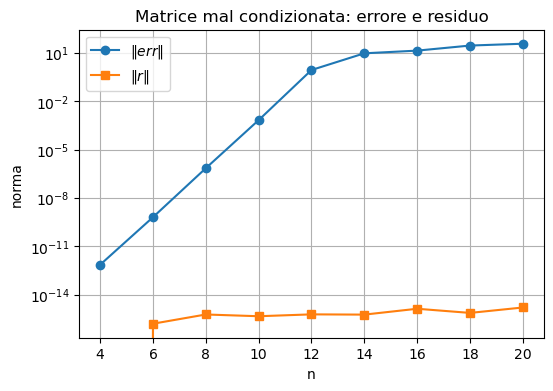

n= 4  cond_2(H)=1.551e+04  ||err||=7.175e-13  ||r||=0.000e+00
n= 6  cond_2(H)=1.495e+07  ||err||=6.401e-10  ||r||=1.570e-16
n= 8  cond_2(H)=1.526e+10  ||err||=7.040e-07  ||r||=5.875e-16
n=10  cond_2(H)=1.603e+13  ||err||=6.794e-04  ||r||=4.578e-16
n=12  cond_2(H)=1.678e+16  ||err||=8.767e-01  ||r||=5.979e-16
n=14  cond_2(H)=1.894e+17  ||err||=9.530e+00  ||r||=5.769e-16
n=16  cond_2(H)=4.348e+17  ||err||=1.400e+01  ||r||=1.332e-15
n=18  cond_2(H)=3.568e+19  ||err||=2.887e+01  ||r||=7.364e-16
n=20  cond_2(H)=1.932e+18  ||err||=3.752e+01  ||r||=1.597e-15


In [4012]:
# Residuo piccolo non significa necessariamente errore piccolo
# Usiamo matrici di Hilbert, che diventano rapidamente mal condizionate.

import matplotlib.pyplot as plt

def hilbert(n):
    return np.array([[1.0 / (i + j + 1) for j in range(n)] for i in range(n)])

ns = np.arange(4, 21, 2)
errors = []
residuals = []
conds = []

for n in ns:
    H = hilbert(n)
    x_true = np.ones(n)
    b = H @ x_true
    x_comp = np.linalg.solve(H, b)

    err = np.linalg.norm(x_comp - x_true, 2)
    res = np.linalg.norm(b - H @ x_comp, 2)

    errors.append(err)
    residuals.append(res)
    conds.append(np.linalg.cond(H, 2))

plt.figure(figsize=(6, 4))
plt.semilogy(ns, errors, marker="o", label=r"$\|err\|$")
plt.semilogy(ns, residuals, marker="s", label=r"$\|r\|$")
plt.xlabel("n")
plt.ylabel("norma")
plt.title("Matrice mal condizionata: errore e residuo")
plt.legend()
plt.grid(True, which="both")
plt.show()

for n, c, e, r in zip(ns, conds, errors, residuals):
    print(f"n={n:2d}  cond_2(H)={c:.3e}  ||err||={e:.3e}  ||r||={r:.3e}")

>Questo esempio mostra che, per una matrice mal condizionata come la matrice di Hilbert, potremmo avere un piccolo residuo, ma un grande errore sulla soluzione. In questo caso il residuo non è quindi una misura affidabile di accuratezza della soluzione.

## 15. Esempio: una matrice mal condizionata

Consideriamo la matrice

$$
A=
\begin{pmatrix}
1.000 & 2.000\\
0.499 & 1.001
\end{pmatrix}.
$$

Per questa matrice si ha, sia per $p=1$ sia per $p=\infty$,

$$
K_p(A)\simeq 3.001\cdot 10^3.
$$

Poiché $n=2$ e

$$
K_p(A)>10^n,
$$

la matrice può essere considerata **mal condizionata**.

Risolviamo il sistema

$$
Ax^*=b,
$$

cioè

$$
\begin{cases}
1.000x_1^*+2.000x_2^*=3.000,\\
0.499x_1^*+1.001x_2^*=1.500.
\end{cases}
$$

La soluzione esatta è

$$
x_1^*=1,
\qquad
x_2^*=1.
$$

Ora perturbiamo la matrice risolvendo

$$
(A+E)\tilde{x}=b,
\qquad
\|E\|_1=0.001,
$$

ossia

$$
\begin{cases}
1.000\tilde{x}_1+2.000\tilde{x}_2=3.000,\\
0.500\tilde{x}_1+1.002\tilde{x}_2=1.500.
\end{cases}
$$

La soluzione diventa

$$
\tilde{x}_1=3,
\qquad
\tilde{x}_2=0.
$$

In questo caso la perturbazione relativa è

$$
\frac{\|E\|_1}{\|A\|_1}\simeq 3.3322\cdot 10^{-4},
$$

il residuo relativo è

$$
r=\frac{\|A\tilde{x}-b\|}{\|b\|}
\simeq 6.6667\cdot 10^{-4},
$$

ma l'errore relativo sulla soluzione è

$$
\frac{\|\delta x\|_1}{\|x\|_1}\simeq 1.500.
$$

>Questo esempio mostra concretamente che una piccola perturbazione dei dati può produrre un grande errore sulla soluzione quando la matrice è mal condizionata.

In [4013]:
# Riproduzione numerica dell'esempio

A = np.array([[1.000, 2.000],
              [0.499, 1.001]])

b = np.array([3.000, 1.500])

A_tilde = np.array([[1.000, 2.000],
                    [0.500, 1.002]])

E = A_tilde - A

x_star = np.linalg.solve(A, b)
x_tilde = np.linalg.solve(A_tilde, b)

delta_x = x_tilde - x_star

print("A =")
print(A)
print("\ncond_1(A)   =", np.linalg.cond(A, 1))
print("cond_inf(A) =", np.linalg.cond(A, np.inf))
print("\nx*       =", x_star)
print("x_tilde  =", x_tilde)
print("E =")
print(E)

rel_E = np.linalg.norm(E, 1) / np.linalg.norm(A, 1)
rel_res = np.linalg.norm(A @ x_tilde - b, 1) / np.linalg.norm(b, 1)
rel_err = np.linalg.norm(delta_x, 1) / np.linalg.norm(x_star, 1)

print("\n||E||_1 / ||A||_1        =", rel_E)
print("||A x_tilde - b||_1/||b||_1 =", rel_res)
print("||delta x||_1 / ||x||_1 =", rel_err)

A =
[[1.    2.   ]
 [0.499 1.001]]

cond_1(A)   = 3001.0000000001082
cond_inf(A) = 3001.0000000001082

x*       = [1. 1.]
x_tilde  = [3. 0.]
E =
[[0.    0.   ]
 [0.001 0.001]]

||E||_1 / ||A||_1        = 0.000333222259246955
||A x_tilde - b||_1/||b||_1 = 0.0006666666666666919
||delta x||_1 / ||x||_1 = 1.5000000000000833


# Parte IV — Sistemi triangolari

## 16. Sostituzione in avanti


Se $L$ è triangolare inferiore, il sistema

$$
Ly=b
$$

si risolve calcolando le componenti di $y$ dall'alto verso il basso.

Ad esempio, nel caso $n=3$, il sistema triangolare inferiore ha la forma seguente:

$$
\begin{pmatrix}
\ell_{1,1} & 0 & 0 \\
\ell_{2,1} & \ell_{2,2} & 0 \\
\ell_{3,1} & \ell_{3,2} & \ell_{3,3}
\end{pmatrix}
\begin{pmatrix}
y_1 \\
y_2 \\
y_3
\end{pmatrix}
=
\begin{pmatrix}
b_1 \\
b_2 \\
b_3
\end{pmatrix}.
$$

Le incognite si calcolano progressivamente come

$$
y_1 = \frac{b_1}{\ell_{1,1}}
\qquad \text{1 operazione}
$$

$$
\downarrow
$$

$$
y_2 = \frac{b_2 - \ell_{2,1}y_1}{\ell_{2,2}}
\qquad \text{3 operazioni}
$$

$$
\downarrow
$$

$$
y_3 =
\frac{b_3 - \ell_{3,1}y_1 - \ell_{3,2}y_2}{\ell_{3,3}}
\qquad \text{5 operazioni}
$$

In forma compatta:

$$
y_i=
\frac{
b_i-\sum_{j=1}^{i-1}l_{ij}y_j
}{l_{ii}}.
$$

Poiché al passo $i$ si usano solo le componenti già calcolate $y_1,\dots,y_{i-1}$, l'algoritmo procede dall'alto verso il basso.

Il costo computazionale complessivo, per un sistema triangolare inferiore di ordine $n$, è dell'ordine di

$$
n^2.
$$

Lo stesso procedimento può essere scritto in forma algoritmica.

**Pseudocodice — Sostituzione in avanti**

```text
Input:  matrice triangolare inferiore L, termine noto b
Output: soluzione y del sistema Ly = b

for i = 1, ..., n:
    somma = 0

    for j = 1, ..., i-1:
        somma = somma + l_{i,j} y_j

    y_i = (b_i - somma) / l_{i,i}

In [4014]:
def forward_substitution(L, b):
    L = np.array(L, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)
    y = np.zeros(n)

    for i in range(n):
        s = np.dot(L[i, :i], y[:i])
        if abs(L[i, i]) < 1e-15:
            raise ZeroDivisionError("Elemento diagonale nullo nella matrice L.")
        y[i] = (b[i] - s) / L[i, i]

    return y

L = np.array([[2., 0., 0.],
              [1., 3., 0.],
              [4., 2., 1.]])
b = np.array([2., 5., 9.])

y = forward_substitution(L, b)
print("y =", y)
print("L @ y =", L @ y)

y = [1.       1.333333 2.333333]
L @ y = [2. 5. 9.]


## 17. Sostituzione in avanti con diagonale unitaria

Se $L$ ha diagonale unitaria, cioè $l_{ii}=1$, allora

$$
y_i=b_i-\sum_{j=1}^{i-1}l_{ij}y_j.
$$

Questo è frequente nella fattorizzazione LU che vedremo tra poco.

In [4015]:
def forward_substitution_unit_lower(L, b):
    L = np.array(L, dtype=float)
    b = np.array(b, dtype=float)
    n = len(b)
    y = np.zeros(n)

    for i in range(n):
        y[i] = b[i] - np.dot(L[i, :i], y[:i])

    return y

L_unit = np.array([[1., 0., 0.],
                   [2., 1., 0.],
                   [3., 4., 1.]])
b = np.array([2., 1., 2.])

y = forward_substitution_unit_lower(L_unit, b)
print("y =", y)
print("L_unit @ y =", L_unit @ y)

y = [ 2. -3.  8.]
L_unit @ y = [2. 1. 2.]


## 17. Sostituzione all'indietro

Se $U$ è triangolare superiore, il sistema

$$
Ux=b
$$

si risolve calcolando le componenti di $x$ dal basso verso l'alto.

Ad esempio, nel caso $n=3$, il sistema triangolare superiore ha la forma seguente:

$$
\begin{pmatrix}
u_{1,1} & u_{1,2} & u_{1,3} \\
0 & u_{2,2} & u_{2,3} \\
0 & 0 & u_{3,3}
\end{pmatrix}
\begin{pmatrix}
x_1 \\
x_2 \\
x_3
\end{pmatrix}
=
\begin{pmatrix}
b_1 \\
b_2 \\
b_3
\end{pmatrix}.
$$

Le incognite si calcolano progressivamente come

$$
x_3 = \frac{b_3}{u_{3,3}}
\qquad \text{1 operazione}
$$

$$
\downarrow
$$

$$
x_2 = \frac{b_2 - u_{2,3}x_3}{u_{2,2}}
\qquad \text{3 operazioni}
$$

$$
\downarrow
$$

$$
x_1 =
\frac{b_1 - u_{1,2}x_2 - u_{1,3}x_3}{u_{1,1}}
\qquad \text{5 operazioni}
$$

In forma compatta:

$$
x_i=
\frac{
b_i-\sum_{j=i+1}^{n}u_{ij}x_j
}{u_{ii}}.
$$

Poiché al passo $i$ si usano solo le componenti già calcolate $x_{i+1},\dots,x_n$, l'algoritmo procede dal basso verso l'alto.

Il costo computazionale complessivo, per un sistema triangolare superiore di ordine $n$, è dell'ordine di

$$
n^2.
$$

**Pseudocodice — Sostituzione all'indietro**

```text
Input:  matrice triangolare superiore U, termine noto b
Output: soluzione x del sistema Ux = b

for i = n, n-1, ..., 1:
    somma = 0

    for j = i+1, ..., n:
        somma = somma + u_{i,j} x_j

    x_i = (b_i - somma) / u_{i,i}

In [4016]:
def backward_substitution(U, y):
    U = np.array(U, dtype=float)
    y = np.array(y, dtype=float)
    n = len(y)
    x = np.zeros(n)

    for i in range(n - 1, -1, -1):
        s = np.dot(U[i, i+1:], x[i+1:])
        if abs(U[i, i]) < 1e-15:
            raise ZeroDivisionError("Elemento diagonale nullo nella matrice U.")
        x[i] = (y[i] - s) / U[i, i]

    return x

U = np.array([[2., 1., 0.],
              [0., 3., 2.],
              [0., 0., 4.]])
y = np.array([2., -3., 8.])

x = backward_substitution(U, y)
print("x =", x)
print("U @ x =", U @ x)

x = [ 2.166667 -2.333333  2.      ]
U @ x = [ 2. -3.  8.]


# Parte V — Fattorizzazione LU

## 19. Idea della fattorizzazione LU

La fattorizzazione LU scrive $A$ come prodotto di due matrici nella forma

$$
A=LU,
$$

dove:

- $L$ è triangolare inferiore;
- $U$ è triangolare superiore.

Se $A=LU$, allora

$$
Ax=b
\quad\Longleftrightarrow\quad
LUx=b.
$$

Ponendo

$$
Ux=y,
$$

si risolvono, nell'ordine indicato, due sistemi triangolari:

$$
Ly=b,
$$

$$
Ux=y.
$$

>Attenzione: l'ordine di risoluzione dei due sistemi è fondamentale. Possiamo risolvere per primo $Ly=b$, perchè abbiamo tutte le informazioni relative a questo sistema (matrice e termine noto). Mentre non è possibile risolvere per primo $Ux=y$ perchè non possediamo il termine noto $y$. 

## 20. Esistenza della LU senza pivoting

La fattorizzazione LU senza scambi di righe non è garantita per ogni matrice invertibile.

Una condizione sufficiente è che i minori principali di ordine

$$
1,2,\ldots,n-1
$$

siano tutti diversi da zero.

Dato $A\in\mathbb{R}^{n\times n}$, il **minore principale di ordine $k$** è il determinante della sottomatrice ottenuta prendendo le prime $k$ righe e le prime $k$ colonne di $A$:

$$
\Delta_k =
\det
\begin{pmatrix}
a_{11} & a_{12} & \cdots & a_{1k}\\
a_{21} & a_{22} & \cdots & a_{2k}\\
\vdots & \vdots & \ddots & \vdots\\
a_{k1} & a_{k2} & \cdots & a_{kk}
\end{pmatrix},
\qquad k=1,\ldots,n.
$$

Quindi la condizione richiesta per l'esistenza della fattorizzazione LU senza pivoting è

$$
\Delta_k\neq 0,
\qquad k=1,\ldots,n-1.
$$

Se durante l'algoritmo compare un pivot nullo, la LU senza pivoting fallisce.  
Se compare un pivot molto piccolo, l'algoritmo può essere numericamente instabile.

In [4017]:
def lu_no_pivot(A):
    A = np.array(A, dtype=float)
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n)

    for k in range(n - 1):
        if abs(U[k, k]) < 1e-15:
            raise ZeroDivisionError("Pivot nullo: serve pivoting.")
        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] = U[i, k:] - L[i, k] * U[k, k:]
            U[i, k] = 0.0

    return L, U

## 21. Eliminazione di Gauss: passo per passo

Sia

$$
A=
\begin{pmatrix}
a_{11} & a_{12} & a_{13}\\
a_{21} & a_{22} & a_{23}\\
a_{31} & a_{32} & a_{33}
\end{pmatrix}.
$$

Il metodo di Gauss trasforma $A$ in una matrice triangolare superiore $U$ annullando gli elementi sotto la diagonale principale.

Al primo passo si assume

$$
a_{11}\neq 0
$$

e si usa la matrice elementare

$$
L_1=
\begin{pmatrix}
1 & 0 & 0\\
-\dfrac{a_{21}}{a_{11}} & 1 & 0\\
-\dfrac{a_{31}}{a_{11}} & 0 & 1
\end{pmatrix}.
$$

Allora

$$
L_1A=
\begin{pmatrix}
a_{11} & a_{12} & a_{13}\\
0 & a_{22}^{(1)} & a_{23}^{(1)}\\
0 & a_{32}^{(1)} & a_{33}^{(1)}
\end{pmatrix},
$$

dove

$$
a_{ij}^{(1)}=
a_{ij}-\frac{a_{i1}}{a_{11}}a_{1j},
\qquad i,j=2,3.
$$

### Secondo passo

Al secondo passo si assume

$$
a_{22}^{(1)}\neq 0
$$

e si annulla $a_{32}^{(1)}$ tramite

$$
L_2=
\begin{pmatrix}
1&0&0\\
0&1&0\\
0&-\dfrac{a_{32}^{(1)}}{a_{22}^{(1)}}&1
\end{pmatrix}.
$$

Quindi

$$
L_2L_1A=
\begin{pmatrix}
a_{11} & a_{12} & a_{13}\\
0 & a_{22}^{(1)} & a_{23}^{(1)}\\
0 & 0 & a_{33}^{(2)}
\end{pmatrix}
=U,
$$

con

$$
a_{33}^{(2)}
=
a_{33}^{(1)}
-
\frac{a_{32}^{(1)}}{a_{22}^{(1)}}a_{23}^{(1)}.
$$

### Dall'eliminazione alla fattorizzazione LU

Poiché

$$
U=L_2L_1A,
$$

si ha

$$
A=(L_2L_1)^{-1}U=L_1^{-1}L_2^{-1}U.
$$

Ponendo

$$
L=L_1^{-1}L_2^{-1},
$$

si ottiene

$$
\boxed{A=LU}.
$$

Nel caso $3\times 3$,

$$
L=
\begin{pmatrix}
1 & 0 & 0\\
\dfrac{a_{21}}{a_{11}} & 1 & 0\\
\dfrac{a_{31}}{a_{11}} &
\dfrac{a_{32}^{(1)}}{a_{22}^{(1)}} & 1
\end{pmatrix}.
$$

La matrice $L$ è triangolare inferiore a diagonale unitaria, mentre $U$ è triangolare superiore.

In [4018]:
def lu_no_pivot_verbose(A):
    A = np.array(A, dtype=float)
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n)

    print("U iniziale:")
    print(U)

    for k in range(n - 1):
        print(f"\nPasso k={k}")
        print("Pivot =", U[k, k])

        if abs(U[k, k]) < 1e-15:
            raise ZeroDivisionError("Pivot nullo.")

        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            print(f"Moltiplicatore L[{i},{k}] =", L[i, k])
            U[i, k:] = U[i, k:] - L[i, k] * U[k, k:]
            U[i, k] = 0.0

        print("U aggiornata:")
        print(U)

    return L, U

A = np.array([[2., 1., 0.],
              [4., 5., 2.],
              [6., 15., 12.]])

L, U = lu_no_pivot_verbose(A)
print("\nL finale:")
print(L)
print("\nU finale:")
print(U)
print("\nErrore A-LU:", np.linalg.norm(A - L @ U))

U iniziale:
[[ 2.  1.  0.]
 [ 4.  5.  2.]
 [ 6. 15. 12.]]

Passo k=0
Pivot = 2.0
Moltiplicatore L[1,0] = 2.0
Moltiplicatore L[2,0] = 3.0
U aggiornata:
[[ 2.  1.  0.]
 [ 0.  3.  2.]
 [ 0. 12. 12.]]

Passo k=1
Pivot = 3.0
Moltiplicatore L[2,1] = 4.0
U aggiornata:
[[2. 1. 0.]
 [0. 3. 2.]
 [0. 0. 4.]]

L finale:
[[1. 0. 0.]
 [2. 1. 0.]
 [3. 4. 1.]]

U finale:
[[2. 1. 0.]
 [0. 3. 2.]
 [0. 0. 4.]]

Errore A-LU: 0.0


## 22. Soluzione completa con LU

Data la fattorizzazione

$$
A=LU,
$$

la soluzione di $Ax=b$ avviene così:

1. risolvi $Ly=b$ con sostituzione in avanti;
2. risolvi $Ux=y$ con sostituzione all'indietro.

In [4019]:
A = np.array([[2., 1., 0.],
              [4., 5., 2.],
              [6., 15., 12.]])
b = np.array([2., 1., 2.])

L, U = lu_no_pivot(A)
y = forward_substitution(L, b)
x = backward_substitution(U, y)

print("L =")
print(L)
print("\nU =")
print(U)
print("\ny =", y)
print("x =", x)
print("Residuo ||Ax-b|| =", np.linalg.norm(A @ x - b))
print("Soluzione NumPy =", np.linalg.solve(A, b))

L =
[[1. 0. 0.]
 [2. 1. 0.]
 [3. 4. 1.]]

U =
[[2. 1. 0.]
 [0. 3. 2.]
 [0. 0. 4.]]

y = [ 2. -3.  8.]
x = [ 2.166667 -2.333333  2.      ]
Residuo ||Ax-b|| = 6.280369834735101e-16
Soluzione NumPy = [ 2.166667 -2.333333  2.      ]


## 23. Costo computazionale della LU

La fattorizzazione LU tramite eliminazione di Gauss ha costo dell'ordine di
$\frac{1}{3}n^3$
moltiplicazioni/divisioni, più un numero comparabile di somme/sottrazioni, quindi il costo computazionale totale è dellordine di $$\frac23n^3$$

Le due sostituzioni triangolari costano ciascuna circa $n^2$.  
Per $n$ grande, il costo dominante è quindi la fattorizzazione.

### Dettagli 
Per costruire i moltiplicatori servono

$$
(n-1)+(n-2)+\dots+1
=
\sum_{i=1}^{n-1} i
=
\frac{n(n-1)}{2}
$$

divisioni.

Per aggiornare la matrice si lavora su blocchi di dimensione

$$
(n-1)\times(n-1),\quad
(n-2)\times(n-2),\quad
\dots,\quad
1\times1.
$$

Il numero di moltiplicazioni è

$$
(n-1)^2+(n-2)^2+\dots+1^2
=
\sum_{i=1}^{n-1} i^2
=
\frac{(n-1)n(2n-1)}{6}.
$$

In totale:

$$
\frac{n(n-1)}{2}
+
\frac{(n-1)n(2n-1)}{6}
=
\frac{n^3-n}{3}
\approx
\frac{1}{3}n^3.
$$


## 6. Esempio di fattorizzazione LU

Consideriamo

$$
A=
\begin{pmatrix}
2&1&0\\
4&5&2\\
6&15&12
\end{pmatrix},
\qquad
b=
\begin{pmatrix}
2\\
1\\
2
\end{pmatrix}.
$$

L'eliminazione produce

$$
L=
\begin{pmatrix}
1&0&0\\
2&1&0\\
3&4&1
\end{pmatrix},
\qquad
U=
\begin{pmatrix}
2&1&0\\
0&3&2\\
0&0&4
\end{pmatrix}.
$$

Quindi

$$
A=LU.
$$

## 9. Calcolo del determinante

Se

$$
A=LU,
$$

allora, per il teorema di Binet,

$$
\det(A)=\det(L)\det(U).
$$

Poiché $L$ ha diagonale unitaria,

$$
\det(L)=1.
$$

Quindi

$$
\det(A)=\det(U).
$$

Essendo $U$ triangolare superiore,

$$
\det(U)=\prod_{i=1}^n u_{ii}.
$$

Nel caso senza scambi di righe:

$$
\boxed{
\det(A)=\prod_{i=1}^n u_{ii}
}.
$$

In [4020]:
det_lu = np.prod(np.diag(U))
det_np = np.linalg.det(A)

print("det(A) tramite LU:", det_lu)
print("det(A) tramite NumPy:", det_np)

det(A) tramite LU: 24.0
det(A) tramite NumPy: 24.000000000000004


## 8. Calcolo dell'inversa

Se $A$ è invertibile,

$$
AA^{-1}=I_n.
$$

Scrivendo

$$
A^{-1}=
\left(
\begin{array}{c|c|c|c}
x_1 & x_2 & \cdots & x_n
\end{array}
\right),
\qquad
I_n=
\left(
\begin{array}{c|c|c|c}
e_1 & e_2 & \cdots & e_n
\end{array}
\right).
$$

il calcolo dell'inversa equivale a risolvere $n$ sistemi lineari:

$$
Ax_1=e_1,\quad
Ax_2=e_2,\quad
\dots,\quad
Ax_n=e_n.
$$

Se $A=LU$, per ogni colonna si risolvono

$$
Ly_i=e_i,
\qquad
Ux_i=y_i.
$$

In [4021]:
def inverse_from_lu(A):
    A = np.array(A, dtype=float)
    n = A.shape[0]
    L, U = lu_no_pivot(A)
    X = np.zeros_like(A)
    I = np.eye(n)

    for j in range(n):
        y = forward_substitution(L, I[:, j])
        X[:, j] = backward_substitution(U, y)

    return X

A_inv_lu = inverse_from_lu(A)
A_inv_np = np.linalg.inv(A)

print("Inversa tramite LU:")
print(A_inv_lu)
print("\nErrore rispetto a NumPy:", np.linalg.norm(A_inv_lu - A_inv_np))

Inversa tramite LU:
[[ 1.25     -0.5       0.083333]
 [-1.5       1.       -0.166667]
 [ 1.25     -1.        0.25    ]]

Errore rispetto a NumPy: 6.922220526417403e-16


# Parte VI — Pivoting e stabilità

## 26. Matrici di permutazione

Una matrice di permutazione si ottiene permutando (ovvero scambiando) le righe della matrice identità.

Ad esempio, partendo dalla matrice identità di ordine 3,

$$
I_3=
\begin{pmatrix}
1&0&0\\
0&1&0\\
0&0&1
\end{pmatrix},
$$

scambiando la prima e la terza riga si ottiene la matrice di permutazione

$$
P=
\begin{pmatrix}
0&0&1\\
0&1&0\\
1&0&0
\end{pmatrix}.
$$

Se

$$
A=
\begin{pmatrix}
a_{11}&a_{12}&a_{13}\\
a_{21}&a_{22}&a_{23}\\
a_{31}&a_{32}&a_{33}
\end{pmatrix},
$$

allora

$$
PA=
\begin{pmatrix}
a_{31}&a_{32}&a_{33}\\
a_{21}&a_{22}&a_{23}\\
a_{11}&a_{12}&a_{13}
\end{pmatrix}.
$$

Quindi $PA$ è la matrice ottenuta da $A$ scambiando la prima e la terza riga.


In generale, se $P$ è una matrice di permutazione:

- $PA$ permuta le righe di $A$;
- $AP$ permuta le colonne di $A$.

Queste matrici permettono di descrivere formalmente gli scambi di righe usati nel _pivoting_ che verrà introdotto nella sezione seguente.

Inoltre,

$$
P^{-1}=P^T.
$$

In [4022]:
A_demo = np.array([[1., 2., 3.],
                   [4., 5., 6.],
                   [7., 8., 9.]])

P = np.array([[1., 0., 0.],
              [0., 0., 1.],
              [0., 1., 0.]])

print("A =")
print(A_demo)
print("\nP @ A: righe permutate")
print(P @ A_demo)
print("\nA @ P: colonne permutate")
print(A_demo @ P)

A =
[[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]

P @ A: righe permutate
[[1. 2. 3.]
 [7. 8. 9.]
 [4. 5. 6.]]

A @ P: colonne permutate
[[1. 3. 2.]
 [4. 6. 5.]
 [7. 9. 8.]]


## 10. Scambio di righe e matrici di permutazione

La fattorizzazione senza pivoting può fallire se un pivot è nullo.

Ad esempio,

$$
\begin{pmatrix}
0&3\\
1&2
\end{pmatrix}
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}
=
\begin{pmatrix}
5\\
0
\end{pmatrix}
$$

ha $a_{11}=0$.

Scambiando le righe si ottiene

$$
\begin{pmatrix}
1&2\\
0&3
\end{pmatrix}
\begin{pmatrix}
x_1\\
x_2
\end{pmatrix}
=
\begin{pmatrix}
0\\
5
\end{pmatrix}.
$$


## 11. Fattorizzazione con pivoting parziale

Con scambio di righe si cerca una matrice di permutazione $P$ tale che

$$
PA=LU.
$$

Per risolvere

$$
Ax=b,
$$

si moltiplica a sinistra per $P$:

$$
PAx=Pb.
$$

Poiché

$$
PA=LU,
$$

si ottiene

$$
LUx=Pb.
$$

Quindi si risolvono

$$
Ly=Pb,
\qquad
Ux=y.
$$

Gli stessi scambi di righe applicati ad $A$ devono essere applicati anche a $b$.
## 12. Teorema con pivoting

**Teorema.**  
Per ogni matrice

$$
A\in\mathbb{R}^{n\times n}
$$

esiste una matrice di permutazione $P$ tale che

$$
PA=LU,
$$

dove $L$ è triangolare inferiore con diagonale unitaria e $U$ è triangolare superiore.

Se $A$ è non singolare, la fattorizzazione si effettua in $n-1$ passi.

Se $A$ è singolare, il procedimento si arresta quando si incontra un pivot nullo non eliminabile.



In [4023]:
def lu_partial_pivot(A):
    A = np.array(A, dtype=float)
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n)
    P = np.eye(n)

    for k in range(n - 1):
        pivot = k + np.argmax(np.abs(U[k:, k]))

        if abs(U[pivot, k]) < 1e-15:
            raise ZeroDivisionError("Matrice singolare o pivot nullo.")

        if pivot != k:
            U[[k, pivot], :] = U[[pivot, k], :]
            P[[k, pivot], :] = P[[pivot, k], :]

            if k > 0:
                L[[k, pivot], :k] = L[[pivot, k], :k]

        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] = U[i, k:] - L[i, k] * U[k, k:]

    return P, L, U


## 13. Esempio di pivoting parziale

Consideriamo

$$
A=
\begin{pmatrix}
4&-8&2\\
2&-4&6\\
1&-1&3
\end{pmatrix}.
$$

Alla prima colonna, il massimo in modulo è $4$, quindi non serve scambiare la prima riga.

Dopo il primo passo:

$$
A_1=
\begin{pmatrix}
4&-8&2\\
0&0&5\\
0&1&\frac{5}{2}
\end{pmatrix}.
$$

Il pivot successivo sarebbe $0$, quindi si scambiano la seconda e la terza riga:

$$
P_2=
\begin{pmatrix}
1&0&0\\
0&0&1\\
0&1&0
\end{pmatrix}.
$$

Si ottiene

$$
P_2A_1=
\begin{pmatrix}
4&-8&2\\
0&1&\frac{5}{2}\\
0&0&5
\end{pmatrix}.
$$


In [4024]:
A_piv = np.array([
    [4, -8, 2],
    [2, -4, 6],
    [1, -1, 3]
], dtype=float)

P, L, U = lu_partial_pivot(A_piv)

print("P =")
print(P)
print("\nL =")
print(L)
print("\nU =")
print(U)
print("\nVerifica P @ A = L @ U:", np.allclose(P @ A_piv, L @ U))

P =
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]

L =
[[1.   0.   0.  ]
 [0.25 1.   0.  ]
 [0.5  0.   1.  ]]

U =
[[ 4.  -8.   2. ]
 [ 0.   1.   2.5]
 [ 0.   0.   5. ]]

Verifica P @ A = L @ U: True




## 14. Stabilità della fattorizzazione LU

In aritmetica finita si ottengono matrici perturbate

$$
\widetilde{L}=L+\delta L,
\qquad
\widetilde{U}=U+\delta U.
$$

Quindi

$$
\widetilde{L}\widetilde{U}=A+\delta A.
$$

Poiché $A=LU$,

$$
A+\delta A
=
(L+\delta L)(U+\delta U)
=
LU+\delta L\,U+L\,\delta U+\delta L\,\delta U.
$$

Perciò

$$
\delta A=
\delta L\,U+L\,\delta U+\delta L\,\delta U.
$$

>La relazione precedente dice che fattorizzazione LU è stabile se gli elementi di $L$ e $U$ non crescono troppo rispetto agli elementi di $A$.

- **Stabilità forte:** esistono costanti $a,b$ indipendenti dall'ordine della matrice tali che

$$
|\ell_{ij}|\leq a,
\qquad
|u_{ij}|\leq b.
$$

- **Stabilità debole:** le costanti possono dipendere dall'ordine $n$.
## 15. Pivoting e stabilità

Durante l'eliminazione,

$$
\ell_{ik}=
\frac{a_{ik}^{(k-1)}}{a_{kk}^{(k-1)}},
\qquad
i=k+1,\dots,n.
$$

Se il pivot $a_{kk}^{(k-1)}$ è piccolo, i moltiplicatori possono diventare molto grandi.

Con il **pivoting parziale**, si sceglie come pivot l'elemento di massimo modulo nella colonna corrente:

$$
|a_{kk}^{(k-1)}|
\geq
|a_{ik}^{(k-1)}|,
\qquad i=k,\dots,n.
$$

Allora

$$
|\ell_{ik}|
=
\left|
\frac{a_{ik}^{(k-1)}}{a_{kk}^{(k-1)}}
\right|
\leq 1.
$$

Gli elementi di $L$ restano limitati.

Gli elementi di $U$ possono crescere, ma vale

$$
\max_{i,j}|u_{ij}|
\leq
2^{n-1}\max_{i,j}|a_{ij}|.
$$

Quindi il pivoting parziale genera una fattorizzazione stabile in senso debole.
## 16. Esempio di instabilità senza pivoting

Consideriamo

$$
A=
\begin{pmatrix}
10^{-20}&1\\
1&1
\end{pmatrix},
\qquad
b=
\begin{pmatrix}
1\\
2
\end{pmatrix}.
$$

La soluzione esatta è circa

$$
x_1\approx 1,
\qquad
x_2\approx 1.
$$

Senza pivoting, il primo pivot è $10^{-20}$ e il moltiplicatore è

$$
\ell_{21}
=
\frac{1}{10^{-20}}
=
10^{20}.
$$

Questo valore enorme può produrre una forte perdita di precisione in aritmetica finita.


In [4025]:

A_bad = np.array([
    [1e-20, 1],
    [1, 1]
], dtype=float)

b_bad = np.array([1, 2], dtype=float)

print("Soluzione con numpy:")
print(np.linalg.solve(A_bad, b_bad))

try:
    L_bad, U_bad = lu_no_pivot(A_bad)
    y_bad = forward_substitution(L_bad, b_bad)
    x_bad = backward_substitution(U_bad, y_bad)

    print("\nSenza pivoting:")
    print("L =")
    print(L_bad)
    print("U =")
    print(U_bad)
    print("x =", x_bad)
except Exception as e:
    print("Errore:", e)

P_bad, Lp_bad, Up_bad = lu_partial_pivot(A_bad)
yp_bad = forward_substitution(Lp_bad, P_bad @ b_bad)
xp_bad = backward_substitution(Up_bad, yp_bad)

print("\nCon pivoting parziale:")
print("P =")
print(P_bad)
print("L =")
print(Lp_bad)
print("U =")
print(Up_bad)
print("x =", xp_bad)


Soluzione con numpy:
[1. 1.]
Errore: Pivot nullo: serve pivoting.

Con pivoting parziale:
P =
[[0. 1.]
 [1. 0.]]
L =
[[1. 0.]
 [0. 1.]]
U =
[[1. 1.]
 [0. 1.]]
x = [1. 1.]



## 17. Esempio con pivoting

Con pivoting parziale si usa

$$
P_1=
\begin{pmatrix}
0&1\\
1&0
\end{pmatrix}.
$$

Allora

$$
P_1A=
\begin{pmatrix}
1&1\\
10^{-20}&1
\end{pmatrix},
\qquad
P_1b=
\begin{pmatrix}
2\\
1
\end{pmatrix}.
$$

La fattorizzazione produce circa

$$
L=
\begin{pmatrix}
1&0\\
10^{-20}&1
\end{pmatrix},
\qquad
U=
\begin{pmatrix}
1&1\\
0&1
\end{pmatrix}.
$$

Risolvendo

$$
Ly=P_1b,
\qquad
Ux=y,
$$

si ottiene numericamente

$$
x_1=1,\qquad x_2=1.
$$

La soluzione numerica coincide, nella precisione di calcolo, con la soluzione analitica.
## 18. Riassunto operativo

Per risolvere

$$
Ax=b
$$

tramite il metodo di Gauss:

### Senza pivoting

Se non servono scambi di righe,

$$
A=LU.
$$

Si risolvono

$$
Ly=b,
\qquad
Ux=y.
$$

### Con pivoting parziale

Se servono scambi di righe,

$$
PA=LU.
$$

Allora

$$
LUx=Pb.
$$

Si risolvono

$$
Ly=Pb,
\qquad
Ux=y.
$$

Il pivoting parziale evita pivot nulli o troppo piccoli e migliora la stabilità numerica.

In [4026]:
def lu_partial_pivot(A):
    A = np.array(A, dtype=float)
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n)
    P = np.eye(n)

    for k in range(n - 1):
        pivot = np.argmax(np.abs(U[k:, k])) + k

        if abs(U[pivot, k]) < 1e-15:
            raise np.linalg.LinAlgError("Pivot nullo: matrice singolare o quasi singolare.")

        if pivot != k:
            U[[k, pivot], :] = U[[pivot, k], :]
            P[[k, pivot], :] = P[[pivot, k], :]
            if k > 0:
                L[[k, pivot], :k] = L[[pivot, k], :k]

        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
            U[i, k] = 0.0

    return P, L, U

A = np.array([[0., 3.],
              [1., 2.]])

P, L, U = lu_partial_pivot(A)

print("P =")
print(P)
print("\nL =")
print(L)
print("\nU =")
print(U)
print("\nP @ A =")
print(P @ A)
print("\nL @ U =")
print(L @ U)

P =
[[0. 1.]
 [1. 0.]]

L =
[[1. 0.]
 [0. 1.]]

U =
[[1. 2.]
 [0. 3.]]

P @ A =
[[1. 2.]
 [0. 3.]]

L @ U =
[[1. 2.]
 [0. 3.]]


In [4027]:
def solve_lu_pivot(A, b):
    P, L, U = lu_partial_pivot(A)
    y = forward_substitution(L, P @ b)
    x = backward_substitution(U, y)
    return x

A = np.array([[0., 3.],
              [1., 2.]])
b = np.array([5., 0.])

x = solve_lu_pivot(A, b)

print("x =", x)
print("A @ x =", A @ x)
print("b =", b)

x = [-3.333333  1.666667]
A @ x = [5. 0.]
b = [5. 0.]


# Parte VII — Matrici tridiagonali e algoritmo di Thomas

## 31. Matrici tridiagonali

Una matrice tridiagonale ha elementi non nulli solo su tre diagonali:

$$
A=
\begin{pmatrix}
c_1 & e_1 & 0 & \cdots & 0\\
d_2 & c_2 & e_2 & \ddots & \vdots\\
0 & d_3 & c_3 & \ddots & 0\\
\vdots & \ddots & \ddots & \ddots & e_{n-1}\\
0 & \cdots & 0 & d_n & c_n
\end{pmatrix}.
$$

Sono importanti perché compaiono spesso nella discretizzazione di problemi differenziali e in modelli con interazioni locali.

## 32. Algoritmo di Thomas

Per una matrice tridiagonale la fattorizzazione LU si semplifica.

I fattori hanno la forma:

$$
L=
\begin{pmatrix}
1\\
\beta_2 & 1\\
& \beta_3 & 1\\
& & \ddots & \ddots\\
& & & \beta_n & 1
\end{pmatrix},
$$

$$
U=
\begin{pmatrix}
\omega_1 & \gamma_1\\
& \omega_2 & \gamma_2\\
& & \ddots & \ddots\\
& & & \omega_{n-1} & \gamma_{n-1}\\
& & & & \omega_n
\end{pmatrix}.
$$

Le relazioni sono:

$$
\gamma_i=e_i,
$$

$$
\omega_1=c_1,
$$

$$
\beta_i=\frac{d_i}{\omega_{i-1}},
$$

$$
\omega_i=c_i-\beta_i\gamma_{i-1}.
$$

Il costo totale è $O(n)$, molto più basso di $O(n^3)$.

In [4028]:
def thomas_algorithm(d, c, e, b):
    d = np.array(d, dtype=float)
    c = np.array(c, dtype=float)
    e = np.array(e, dtype=float)
    b = np.array(b, dtype=float)

    n = len(c)
    omega = np.zeros(n)
    beta = np.zeros(n)
    gamma = e.copy()

    omega[0] = c[0]

    for i in range(1, n):
        beta[i] = d[i-1] / omega[i-1]
        omega[i] = c[i] - beta[i] * gamma[i-1]

    y = np.zeros(n)
    y[0] = b[0]

    for i in range(1, n):
        y[i] = b[i] - beta[i] * y[i-1]

    x = np.zeros(n)
    x[-1] = y[-1] / omega[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (y[i] - gamma[i] * x[i+1]) / omega[i]

    return x, beta, omega, gamma

In [4029]:
n = 5
d = -np.ones(n-1)
c =  2*np.ones(n)
e = -np.ones(n-1)
b = np.ones(n)

x, beta, omega, gamma = thomas_algorithm(d, c, e, b)

A_tri = np.diag(c) + np.diag(d, -1) + np.diag(e, 1)

print("A =")
print(A_tri)
print("\nbeta =", beta)
print("omega =", omega)
print("gamma =", gamma)
print("\nx =", x)
print("Residuo:", np.linalg.norm(A_tri @ x - b))
print("Soluzione NumPy:", np.linalg.solve(A_tri, b))

A =
[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]

beta = [ 0.       -0.5      -0.666667 -0.75     -0.8     ]
omega = [2.       1.5      1.333333 1.25     1.2     ]
gamma = [-1. -1. -1. -1.]

x = [2.5 4.  4.5 4.  2.5]
Residuo: 2.0350724194510405e-15
Soluzione NumPy: [2.5 4.  4.5 4.  2.5]


## 33. Esperimento sui tempi

L'algoritmo di Thomas sfrutta il fatto che la matrice è descritta solo da tre diagonali.  
Questo permette di evitare sia la memorizzazione della matrice piena sia il costo cubico della LU generale.

In [4030]:
for n in [100, 500, 1000]:
    d = -np.ones(n-1)
    c =  2*np.ones(n)
    e = -np.ones(n-1)
    b = np.ones(n)

    t0 = time.perf_counter()
    x, *_ = thomas_algorithm(d, c, e, b)
    t1 = time.perf_counter()

    print(f"n={n:4d}: tempo Thomas = {t1-t0:.6f} secondi")

n= 100: tempo Thomas = 0.000102 secondi
n= 500: tempo Thomas = 0.000502 secondi
n=1000: tempo Thomas = 0.000995 secondi


# Parte VIII — Fattorizzazione di Cholesky

## 34. Matrici simmetriche definite positive

Una matrice $A$ è simmetrica se

$$
A=A^T.
$$

È definita positiva se

$$
x^TAx>0
$$

per ogni vettore non nullo $x$.

Queste matrici sono molto importanti nelle applicazioni e permettono una fattorizzazione più efficiente della LU.

In [4031]:
A = np.array([[4., 2., 2.],
              [2., 10., 4.],
              [2., 4., 9.]])

print("A =")
print(A)
print("\nA simmetrica?", np.allclose(A, A.T))
print("Autovalori:", np.linalg.eigvalsh(A))
print("Definita positiva?", np.all(np.linalg.eigvalsh(A) > 0))

A =
[[ 4.  2.  2.]
 [ 2. 10.  4.]
 [ 2.  4.  9.]]

A simmetrica? True
Autovalori: [ 3.213894  5.48137  14.304736]
Definita positiva? True


## 35. Fattorizzazione di Cholesky

Se $A$ è simmetrica e definita positiva, allora esiste un'unica matrice triangolare inferiore $L$, con diagonale positiva, tale che

$$
A=LL^T.
$$

Equivalentemente, usando una triangolare superiore $S$,

$$
A=S^TS.
$$

La fattorizzazione di Cholesky costa circa $\frac{1}{6}n^3$ moltiplicazioni/divisioni ed un numero analogo di addizioni/sottrazioni cioè circa metà della LU generale.

In [4032]:
L = np.linalg.cholesky(A)

print("L =")
print(L)
print("\nL @ L.T =")
print(L @ L.T)
print("\nErrore:", np.linalg.norm(A - L @ L.T))

L =
[[2.       0.       0.      ]
 [1.       3.       0.      ]
 [1.       1.       2.645751]]

L @ L.T =
[[ 4.  2.  2.]
 [ 2. 10.  4.]
 [ 2.  4.  9.]]

Errore: 0.0


## 36. Implementazione didattica di Cholesky

Per costruire $L$ tale che

$$
A=LL^T,
$$

si usano:

$$
l_{jj}=
\sqrt{
a_{jj}-\sum_{k=1}^{j-1}l_{jk}^2
},
$$

$$
l_{ij}=
\frac{
a_{ij}-\sum_{k=1}^{j-1}l_{ik}l_{jk}
}{l_{jj}}.
$$

Se $A$ non è definita positiva, può comparire una quantità non positiva sotto radice.

In [4033]:
def cholesky_lower(A):
    A = np.array(A, dtype=float)
    n = A.shape[0]
    L = np.zeros_like(A)

    for j in range(n):
        s = np.dot(L[j, :j], L[j, :j])
        diag = A[j, j] - s

        if diag <= 0:
            raise np.linalg.LinAlgError("La matrice non è definita positiva.")

        L[j, j] = np.sqrt(diag)

        for i in range(j + 1, n):
            s = np.dot(L[i, :j], L[j, :j])
            L[i, j] = (A[i, j] - s) / L[j, j]

    return L

L2 = cholesky_lower(A)
print("L implementata =")
print(L2)
print("\nErrore:", np.linalg.norm(A - L2 @ L2.T))

L implementata =
[[2.       0.       0.      ]
 [1.       3.       0.      ]
 [1.       1.       2.645751]]

Errore: 0.0


## 37. Risoluzione con Cholesky

Se

$$
A=LL^T,
$$

allora

$$
Ax=b
$$

diventa

$$
LL^Tx=b.
$$

Ponendo

$$
L^Tx=y,
$$

si risolvono:

$$
Ly=b,
$$

$$
L^Tx=y.
$$

In [4034]:
b = np.array([1., 2., 3.])

L = cholesky_lower(A)
y = forward_substitution(L, b)
x = backward_substitution(L.T, y)

print("x =", x)
print("Residuo:", np.linalg.norm(A @ x - b))
print("Soluzione NumPy:", np.linalg.solve(A, b))

x = [0.071429 0.071429 0.285714]
Residuo: 0.0
Soluzione NumPy: [0.071429 0.071429 0.285714]


# Parte IX — Fattorizzazione QR e Householder

## 38. Matrici ortogonali

Una matrice $Q$ è ortogonale se

$$
Q^TQ=I.
$$

Quindi

$$
Q^{-1}=Q^T.
$$

Le matrici ortogonali preservano la norma euclidea:

$$
\|Qa\|_2=\|a\|_2.
$$

Infatti

$$
\|Qa\|_2^2=(Qa)^T(Qa)
=a^TQ^TQa
=a^Ta
=\|a\|_2^2.
$$

In [4035]:
theta = np.pi / 6

Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

a = np.array([3., 4.])

print("Q =")
print(Q)
print("\nQ.T @ Q =")
print(Q.T @ Q)
print("\n||a||_2 =", np.linalg.norm(a))
print("||Q @ a||_2 =", np.linalg.norm(Q @ a))

Q =
[[ 0.866025 -0.5     ]
 [ 0.5       0.866025]]

Q.T @ Q =
[[1. 0.]
 [0. 1.]]

||a||_2 = 5.0
||Q @ a||_2 = 5.0


## 39. Fattorizzazione QR

La fattorizzazione QR scrive

$$
A=QR,
$$

dove:

- $Q$ è ortogonale;
- $R$ è triangolare superiore.

Il sistema

$$
Ax=b
$$

diventa

$$
QRx=b.
$$

Moltiplicando per $Q^T$:

$$
Rx=Q^Tb.
$$

Quindi resta solo un sistema triangolare superiore.

In [4036]:
A = np.array([[72., -144., -144.],
              [-144., -36., -360.],
              [-144., -360., 450.]])

Q, R = np.linalg.qr(A)

print("Q =")
print(Q)
print("\nR =")
print(R)
print("\nErrore A-Q@R =", np.linalg.norm(A - Q @ R))
print("Errore Q.T@Q-I =", np.linalg.norm(Q.T @ Q - np.eye(A.shape[0])))

Q =
[[-0.333333  0.666667  0.666667]
 [ 0.666667 -0.333333  0.666667]
 [ 0.666667  0.666667 -0.333333]]

R =
[[-216. -216.  108.]
 [   0. -324.  324.]
 [   0.    0. -486.]]

Errore A-Q@R = 6.550880341146756e-14
Errore Q.T@Q-I = 2.650405845395331e-16


In [4037]:
b = np.array([1., 2., 3.])

Q, R = np.linalg.qr(A)
y = Q.T @ b
x = backward_substitution(R, y)

print("x =", x)
print("Residuo:", np.linalg.norm(A @ x - b))

x = [-0.006687 -0.00823  -0.002058]
Residuo: 2.220446049250313e-16


## 40. Matrici elementari di Householder

Una matrice di Householder ha la forma

$$
H=I-\beta vv^T,
\qquad
\beta=\frac{2}{v^Tv}.
$$

Questa matrice è simmetrica e ortogonale.

Viene costruita in modo che, dato un vettore $a$,

$$
Ha=\pm\|a\|_2e_1.
$$

Così vengono annullate tutte le componenti di $a$ tranne la prima.

## 41. Costruzione del vettore di Householder

Dato $a$, si costruisce

$$
v=a+\mathrm{sign}(a_1)\|a\|_2e_1.
$$

Poi

$$
H=I-\frac{2}{v^Tv}vv^T.
$$

La scelta del segno serve a ridurre problemi di cancellazione numerica.

In [4038]:
def householder_vector(a):
    a = np.array(a, dtype=float)
    norm_a = np.linalg.norm(a)

    if norm_a == 0:
        return a, 0.0

    sign = 1.0 if a[0] >= 0 else -1.0
    v = a.copy()
    v[0] += sign * norm_a
    beta = 2.0 / np.dot(v, v)

    return v, beta

a = np.array([1., 1., 1.])
v, beta = householder_vector(a)
H = np.eye(3) - beta * np.outer(v, v)

print("a =", a)
print("v =", v)
print("beta =", beta)
print("\nH =")
print(H)
print("\nH @ a =", H @ a)
print("\nH.T @ H =")
print(H.T @ H)

a = [1. 1. 1.]
v = [2.732051 1.       1.      ]
beta = 0.21132486540518713

H =
[[-0.57735  -0.57735  -0.57735 ]
 [-0.57735   0.788675 -0.211325]
 [-0.57735  -0.211325  0.788675]]

H @ a = [-1.732051 -0.       -0.      ]

H.T @ H =
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


## 42. QR tramite Householder

L'algoritmo procede per colonne:

1. costruisce una riflessione $H_1$ che azzera gli elementi sotto il primo pivot;
2. costruisce $H_2$ sulla sottomatrice rimanente;
3. prosegue fino a ottenere $R$ triangolare superiore.

Alla fine:

$$
H_{n-1}\cdots H_1A=R.
$$

Poiché le $H_i$ sono ortogonali,

$$
A=QR.
$$

In [4039]:
def qr_householder(A):
    A = np.array(A, dtype=float)
    m, n = A.shape
    R = A.copy()
    Q = np.eye(m)

    for k in range(min(m - 1, n)):
        a = R[k:, k]
        v, beta = householder_vector(a)

        if beta == 0:
            continue

        H_sub = np.eye(m - k) - beta * np.outer(v, v)
        H = np.eye(m)
        H[k:, k:] = H_sub

        R = H @ R
        Q = Q @ H.T

    return Q, R

Qh, Rh = qr_householder(A)

print("Qh =")
print(Qh)
print("\nRh =")
print(Rh)
print("\nErrore A-Qh@Rh =", np.linalg.norm(A - Qh @ Rh))
print("Errore ortogonalita =", np.linalg.norm(Qh.T @ Qh - np.eye(A.shape[0])))

Qh =
[[-0.333333 -0.666667 -0.666667]
 [ 0.666667  0.333333 -0.666667]
 [ 0.666667 -0.666667  0.333333]]

Rh =
[[-216. -216.  108.]
 [  -0.  324. -324.]
 [  -0.    0.  486.]]

Errore A-Qh@Rh = 1.0442802858320781e-13
Errore ortogonalita = 5.529485313139694e-16


## 43. Costo e stabilità della QR

Per una matrice quadrata $n\times n$, la QR tramite Householder costa circa

$$
\frac{2}{3}n^3
$$

operazioni.

È quindi più costosa della LU, che costa circa

$$
\frac{1}{3}n^3.
$$

Tuttavia la QR è molto stabile perché usa trasformazioni ortogonali, che preservano la norma euclidea.

# Parte X — Confronti ed esercizi

## 44. Confronto su matrice ben condizionata

Per matrici ben condizionate, metodi diversi producono in genere soluzioni molto simili.

In [4040]:
A = np.array([[6., 2., 1.],
              [2., 5., 2.],
              [1., 2., 4.]])
b = np.array([1., 2., 3.])

x_solve = np.linalg.solve(A, b)

L = cholesky_lower(A)
y_chol = forward_substitution(L, b)
x_chol = backward_substitution(L.T, y_chol)

Q, R = np.linalg.qr(A)
x_qr = backward_substitution(R, Q.T @ b)

print("cond(A) =", np.linalg.cond(A))
print("x_solve =", x_solve)
print("x_chol  =", x_chol)
print("x_qr    =", x_qr)

print("\nResiduo solve:", np.linalg.norm(A @ x_solve - b))
print("Residuo chol :", np.linalg.norm(A @ x_chol - b))
print("Residuo qr   :", np.linalg.norm(A @ x_qr - b))

cond(A) = 3.6037071700836143
x_solve = [0.012048 0.120482 0.686747]
x_chol  = [0.012048 0.120482 0.686747]
x_qr    = [0.012048 0.120482 0.686747]

Residuo solve: 0.0
Residuo chol : 0.0
Residuo qr   : 4.965068306494546e-16


## 45. Confronto su matrice mal condizionata

Ora usiamo matrici di Hilbert.  
In questo caso l'errore può crescere perché il problema stesso è mal condizionato.

In [4041]:
for n in [6, 8, 10, 12]:
    A = hilbert(n)
    x_true = np.ones(n)
    b = A @ x_true

    x_solve = np.linalg.solve(A, b)

    Q, R = np.linalg.qr(A)
    x_qr = backward_substitution(R, Q.T @ b)

    err_solve = np.linalg.norm(x_solve - x_true) / np.linalg.norm(x_true)
    err_qr = np.linalg.norm(x_qr - x_true) / np.linalg.norm(x_true)

    print(f"n={n}")
    print(f"  cond(A)   = {np.linalg.cond(A):.3e}")
    print(f"  err solve = {err_solve:.3e}")
    print(f"  err QR    = {err_qr:.3e}")

n=6
  cond(A)   = 1.495e+07
  err solve = 2.613e-10
  err QR    = 5.403e-10
n=8
  cond(A)   = 1.526e+10
  err solve = 2.489e-07
  err QR    = 6.537e-08
n=10
  cond(A)   = 1.603e+13
  err solve = 2.148e-04
  err QR    = 3.558e-04
n=12
  cond(A)   = 1.678e+16
  err solve = 2.531e-01
  err QR    = 8.973e-02


## 46. Esercizio 1 — Norme senza `np.linalg.norm`

Scrivere funzioni che calcolino:

$$
\|x\|_1,\qquad
\|x\|_2,\qquad
\|x\|_\infty.
$$

In [4042]:
def norma_1(x):
    x = np.array(x, dtype=float)
    return np.sum(np.abs(x))

def norma_2(x):
    x = np.array(x, dtype=float)
    return np.sqrt(np.sum(x * x))

def norma_inf(x):
    x = np.array(x, dtype=float)
    return np.max(np.abs(x))

x = np.array([1., -2., 3., -4.])

print(norma_1(x), np.linalg.norm(x, 1))
print(norma_2(x), np.linalg.norm(x, 2))
print(norma_inf(x), np.linalg.norm(x, np.inf))

10.0 10.0
5.477225575051661 5.477225575051661
4.0 4.0


## 47. Esercizio 2 — Errore e residuo

Costruire un sistema scegliendo prima $x_{\text{true}}$, poi ponendo

$$
b=Ax_{\text{true}}.
$$

Risolvere numericamente e confrontare:

$$
\frac{\|\tilde{x}-x_{\text{true}}\|}{\|x_{\text{true}}\|}
$$

con

$$
\|A\tilde{x}-b\|.
$$

In [4043]:
A = np.array([[3., 1.],
              [1., 2.]])
x_true = np.array([1., 1.])
b = A @ x_true

x_num = np.linalg.solve(A, b)

print("cond(A) =", np.linalg.cond(A))
print("errore relativo =", np.linalg.norm(x_num - x_true) / np.linalg.norm(x_true))
print("residuo =", np.linalg.norm(A @ x_num - b))

cond(A) = 2.618033988749896
errore relativo = 0.0
residuo = 0.0


## 48. Esercizio 3 — LU senza pivoting

Provare diverse matrici con `lu_no_pivot`.

Domande:

1. quando funziona?
2. quando fallisce?
3. cosa succede se un pivot è molto piccolo?

In [4044]:
A = np.array([[2., 1., 0.],
              [4., 5., 2.],
              [6., 15., 12.]])

L, U = lu_no_pivot(A)

print("Errore A-LU =", np.linalg.norm(A - L @ U))

Errore A-LU = 0.0


## 49. Esercizio 4 — Pivoting

Costruire una matrice per cui LU senza pivoting fallisce, ma LU con pivoting funziona.

In [4045]:
A = np.array([[0., 1.],
              [1., 1.]])
b = np.array([1., 2.])

P, L, U = lu_partial_pivot(A)
x = solve_lu_pivot(A, b)

print("P =")
print(P)
print("L =")
print(L)
print("U =")
print(U)
print("x =", x)
print("Residuo =", np.linalg.norm(A @ x - b))

P =
[[0. 1.]
 [1. 0.]]
L =
[[1. 0.]
 [0. 1.]]
U =
[[1. 1.]
 [0. 1.]]
x = [1. 1.]
Residuo = 0.0


## 50. Esercizio 5 — Thomas

Risolvere un sistema tridiagonale con diagonale principale $2$ e diagonali secondarie $-1$.

In [4046]:
n = 10
d = -np.ones(n-1)
c = 2*np.ones(n)
e = -np.ones(n-1)
b = np.ones(n)

x_thomas, *_ = thomas_algorithm(d, c, e, b)

A = np.diag(c) + np.diag(d, -1) + np.diag(e, 1)
x_np = np.linalg.solve(A, b)

print("Errore Thomas vs NumPy:", np.linalg.norm(x_thomas - x_np))
print("Residuo Thomas:", np.linalg.norm(A @ x_thomas - b))

Errore Thomas vs NumPy: 0.0
Residuo Thomas: 5.0242958677880805e-15


## 51. Esercizio 6 — Cholesky

Verificare se una matrice è simmetrica definita positiva e risolvere un sistema usando Cholesky.

In [4047]:
A = np.array([[4., 1., 1.],
              [1., 3., 0.],
              [1., 0., 2.]])
b = np.array([1., 2., 3.])

print("Simmetrica?", np.allclose(A, A.T))
print("Autovalori:", np.linalg.eigvalsh(A))

L = cholesky_lower(A)
y = forward_substitution(L, b)
x_chol = backward_substitution(L.T, y)

x_np = np.linalg.solve(A, b)

print("x_chol =", x_chol)
print("x_np   =", x_np)
print("Errore =", np.linalg.norm(x_chol - x_np))

Simmetrica? True
Autovalori: [1.467911 2.652704 4.879385]
x_chol = [-0.368421  0.789474  1.684211]
x_np   = [-0.368421  0.789474  1.684211]
Errore = 2.7194799110210365e-16


## 52. Esercizio 7 — QR con Householder

Usare `qr_householder` su una matrice casuale e verificare:

$$
A\approx QR,
$$

$$
Q^TQ\approx I.
$$

In [4048]:
rng = np.random.default_rng(10)

A = rng.normal(size=(4, 4))

Q, R = qr_householder(A)

print("Errore A-QR =", np.linalg.norm(A - Q @ R))
print("Errore Q.TQ-I =", np.linalg.norm(Q.T @ Q - np.eye(4)))

Errore A-QR = 1.2017114547802893e-15
Errore Q.TQ-I = 7.587084404164046e-16


# Riepilogo finale

La risoluzione numerica di sistemi lineari richiede di considerare:

1. **condizionamento del problema**: dipende da $A$;
2. **stabilità dell'algoritmo**: dipende dal metodo;
3. **costo computazionale**;
4. **struttura della matrice**.

Tabella riassuntiva:

| Tipo di matrice | Metodo consigliato |
|---|---|
| Generica quadrata | LU con pivoting |
| Simmetrica definita positiva | Cholesky |
| Tridiagonale | Thomas |
| Problemi numericamente delicati | QR con Householder |

Regole pratiche:

- non usare Cramer per il calcolo numerico;
- non usare $A^{-1}b$ per risolvere sistemi;
- usare `np.linalg.solve(A,b)` per sistemi generici;
- controllare il numero di condizione;
- sfruttare la struttura della matrice quando possibile.

## Glossario

**Sistema lineare:** equazione $Ax=b$.

**Matrice non singolare:** matrice invertibile.

**Norma:** misura della grandezza di un vettore o matrice.

**Errore assoluto:** $\|\tilde{x}-x\|$.

**Errore relativo:** $\|\tilde{x}-x\|/\|x\|$.

**Numero di condizione:** $K(A)=\|A\|\|A^{-1}\|$.

**Pivot:** elemento usato per eliminare una colonna.

**Pivoting:** scambio di righe per scegliere pivot migliori.

**LU:** fattorizzazione $A=LU$.

**Cholesky:** fattorizzazione $A=LL^T$ per matrici simmetriche definite positive.

**QR:** fattorizzazione $A=QR$, con $Q$ ortogonale.

**Householder:** riflessione ortogonale usata per costruire QR.

**Thomas:** algoritmo lineare per sistemi tridiagonali.